# plots

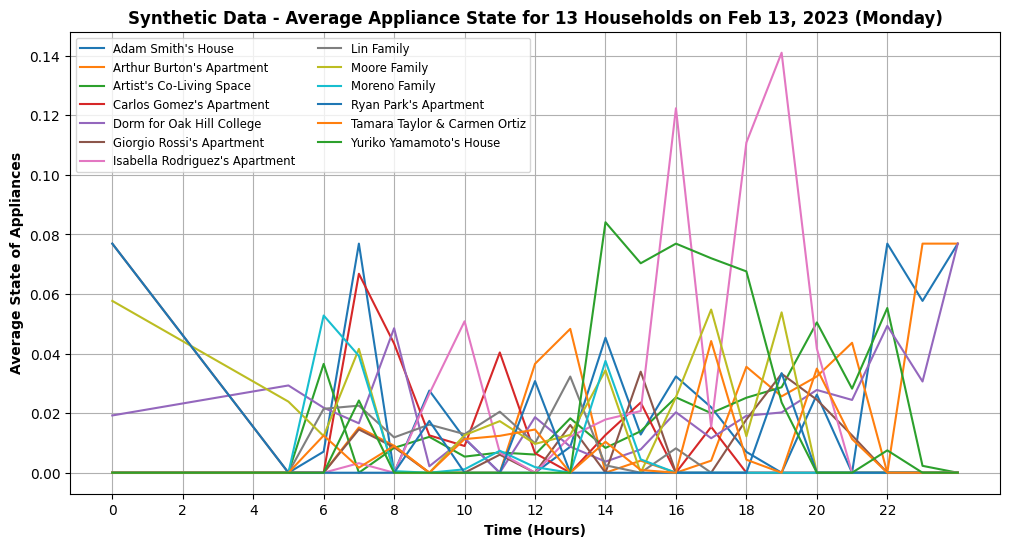

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df_24h = pd.read_csv(r"energy_output_simulation_base_the_ville_n25_30s_run2_1day.csv")

# Define household members
households = {
    "Artist's Co-Living Space": [
        "Latoya Williams", "Rajiv Patel", "Abigail Chen",
        "Francisco Lopez", "Hailey Johnson"
    ],
    "Arthur Burton's Apartment": ["Arthur Burton"],
    "Ryan Park's Apartment": ["Ryan Park"],
    "Isabella Rodriguez's Apartment": ["Isabella Rodriguez"],
    "Giorgio Rossi's Apartment": ["Giorgio Rossi"],
    "Carlos Gomez's Apartment": ["Carlos Gomez"],
    "Adam Smith's House": ["Adam Smith"],
    "Yuriko Yamamoto's House": ["Yuriko Yamamoto"],
    "Moore Family": ["Sam Moore", "Jennifer Moore"],
    "Tamara Taylor & Carmen Ortiz": ["Tamara Taylor", "Carmen Ortiz"],
    "Moreno Family": ["Tom Moreno", "Jane Moreno"],
    "Lin Family": ["John Lin", "Mei Lin", "Eddy Lin"],
    "Dorm for Oak Hill College": [
        "Klaus Mueller", "Maria Lopez", "Ayesha Khan", "Wolfgang Schulz"
    ]
}

# Map each person to a household in df_24h using the households dictionary
df_24h['household'] = df_24h['person'].map({
    person: house for house, members in households.items() for person in members
})

# Add an 'hour' column based on the 'step' (for 30s intervals, 120 steps = 1 hour)
df_24h['hour'] = df_24h['step'] // 120

# Step 1: Sum all `state` values for each household (Total usage per household per hour)

# Step 2: Get the mean usage per household per hour
hourly_avg_state = df_24h.groupby(['hour', 'household'])['state'].mean().reset_index()

# Step 3: Pivot for plotting (reshape DataFrame)
hourly_avg_state = hourly_avg_state.pivot(index='hour', columns='household', values='state').fillna(0)

# Initialize the plot
plt.figure(figsize=(12, 6))

# Loop through each household and plot its data
for household in hourly_avg_state.columns:
    plt.plot(hourly_avg_state.index, hourly_avg_state[household], label=household)

# Customize the plot
plt.title("Synthetic Data - Average Appliance State for 13 Households on Feb 13, 2023 (Monday)", fontweight='bold')
plt.xlabel("Time (Hours)", fontweight='bold')
plt.ylabel("Average State of Appliances", fontweight='bold')
plt.xticks(range(0, 24, 2))  # Set x-axis ticks for every 2 hours
plt.legend(loc="upper left", fontsize='small', ncol=2)  # Add a legend for all households
plt.grid(True)

plt.savefig('household_usage_all_n25_30s_run2_1day.svg')
# Show the plot
plt.show()



File saved: household_hourly_energy_summary.csv


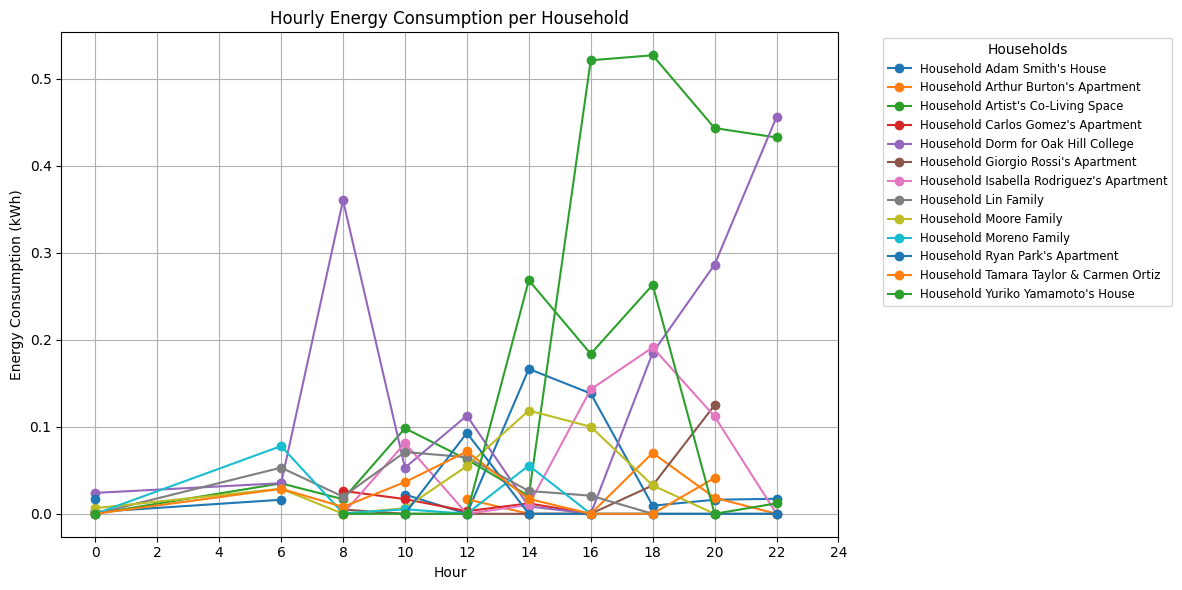

In [ ]:
# Jasmine's code for reverse-engineering. Need to fix to fit into time frame

import numpy as np
# Updated Energy Per Minute Calculation using Real Hourly Distribution
 
# Given real energy distribution percentages per hour
hourly_percentages = np.array([
    0.504, 0.469, 0.440, 0.414, 0.408, 0.450, 0.532, 0.563, 0.569, 0.569,
    0.601, 0.653, 0.703, 0.743, 0.788, 0.865, 0.962, 1.051, 1.076, 1.045,
    0.993, 0.885, 1.386, 0.593
])
 
# Normalize hourly percentages to sum to 1 (convert to proportions)
hourly_weights = hourly_percentages / hourly_percentages.sum()
 
# Total daily consumption per category
total_daily_kwh = 18.71
category_percentages = {
    "heating and cooling": 0.40,
    "water heating": 0.23,
    "appliances": 0.24,
    "lighting": 0.07,
    "cooking": 0.06,
}
 
# Calculate updated hourly consumption per category
updated_hourly_consumption = {
    category: (total_daily_kwh * pct) * hourly_weights for category, pct in category_percentages.items()
}
 
# Convert to energy per minute
updated_energy_per_min = {
    category: updated_hourly_consumption[category] / 60 for category in updated_hourly_consumption
}
 
# Load dataset
# file_path = "/content/drive/MyDrive/updated_7_days_with_household.xlsx"  # Adjust if needed
df = df_24h
 
# Define appliance categories & updated energy per minute values
APPLIANCE_CATEGORIES = {
    "bathroom sink": "water heating",
    "shower": "water heating",
    "refrigerator": "appliances",
    "toaster": "cooking",
    "cooking area": "cooking",
    "guitar": "entertainment",
    "microphone": "entertainment",
    "piano": "entertainment",
    "game console": "appliances",
    "computer desk": "appliances",
    "computer": "appliances",
    "tv": "appliances",
    "light": "lighting"
}
 
df["day"] = df["step"] // 2882  # Day 1 starts at step 0, resets at 1316
df["minute"] = df["step"] % 2880  # Minute within the day
df["hour"] = df["minute"] // 120  # Convert minutes to hours
df["category"] = df["appliance"].map(APPLIANCE_CATEGORIES)
 
# Function to calculate energy consumption with updated per-minute rates
def calculate_energy(row):
    if row["state"]:  # Only count when appliance is ON
        category = row["category"]
        hour = row["hour"]
        return updated_energy_per_min.get(category, np.zeros(24))[hour]  # Get the correct hourly rate
    return 0
 
# Apply function to calculate energy usage per row
df["energy_kWh"] = df.apply(calculate_energy, axis=1)
 
# Summarize results: Group by household, day, hour, and appliance
summary = df.groupby(["household", "day", "hour", "appliance"]).agg({"energy_kWh": "sum"}).reset_index()
 
# Save to a CSV file for easy viewing
save_path = "household_hourly_energy_summary.csv"
summary.to_csv(save_path, index=False)
 
print(f"File saved: {save_path}")
 
import pandas as pd
import matplotlib.pyplot as plt
 
 
# Load the dataset from Google Drive
file_path = "household_hourly_energy_summary.csv"
df = pd.read_csv(file_path)
 
# Ensure necessary columns exist
if "hour" not in df.columns or "energy_kWh" not in df.columns or "household" not in df.columns:
    raise ValueError("Required columns ('hour', 'energy_kWh', 'household') are missing from the dataset.")
 
# Filter for specific hourly intervals (0, 3, 6, 9, ..., 21)
selected_hours = list(range(0, 25, 2))  # Generates [0, 3, 6, 9, 12, 15, 18, 21]
df_filtered = df[df["hour"].isin(selected_hours)]
 
# Aggregate energy consumption per household per hour
df_grouped = df_filtered.groupby(["household", "hour"]).agg({"energy_kWh": "sum"}).reset_index()
 
# Pivot data for plotting
pivot_df = df_grouped.pivot(index="hour", columns="household", values="energy_kWh")
 
# Plot
plt.figure(figsize=(12, 6))
for household in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[household], marker='o', linestyle='-', label=f'Household {household}')
 
plt.xlabel("Hour")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Hourly Energy Consumption per Household")
plt.xticks(selected_hours)
plt.legend(title="Households", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
 
# Save the plot as SVG in Google Drive
plt.savefig('household_usage_all_n25_30s_run2_1day_convert.svg')

 
# Show the plot
plt.show()
 
 

# explore data

## plot all household data and see statistics


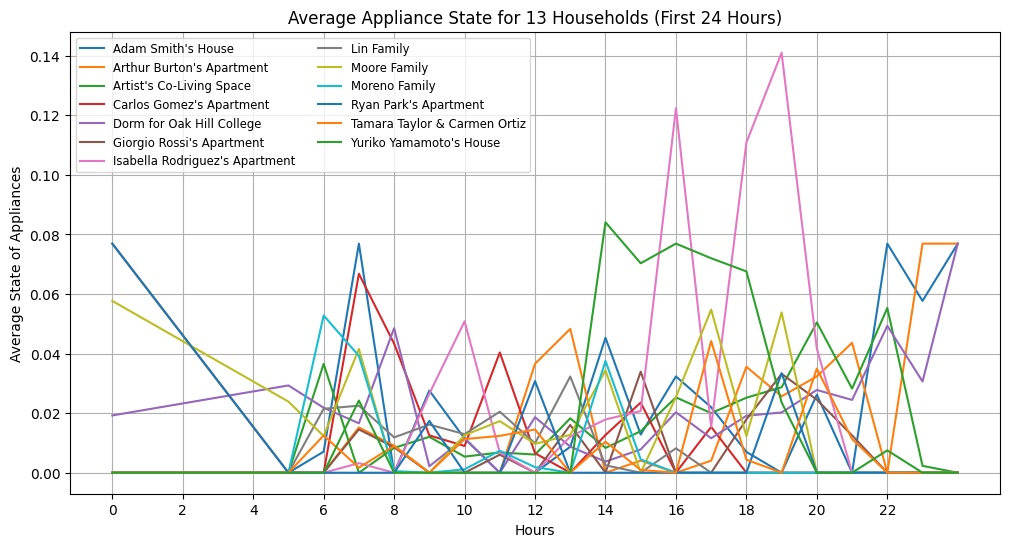

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df_24h = pd.read_csv(r"energy_output_simulation_base_the_ville_n25_30s_run2_1day.csv")

# Define household members
households = {
    "Artist's Co-Living Space": [
        "Latoya Williams", "Rajiv Patel", "Abigail Chen",
        "Francisco Lopez", "Hailey Johnson"
    ],
    "Arthur Burton's Apartment": ["Arthur Burton"],
    "Ryan Park's Apartment": ["Ryan Park"],
    "Isabella Rodriguez's Apartment": ["Isabella Rodriguez"],
    "Giorgio Rossi's Apartment": ["Giorgio Rossi"],
    "Carlos Gomez's Apartment": ["Carlos Gomez"],
    "Adam Smith's House": ["Adam Smith"],
    "Yuriko Yamamoto's House": ["Yuriko Yamamoto"],
    "Moore Family": ["Sam Moore", "Jennifer Moore"],
    "Tamara Taylor & Carmen Ortiz": ["Tamara Taylor", "Carmen Ortiz"],
    "Moreno Family": ["Tom Moreno", "Jane Moreno"],
    "Lin Family": ["John Lin", "Mei Lin", "Eddy Lin"],
    "Dorm for Oak Hill College": [
        "Klaus Mueller", "Maria Lopez", "Ayesha Khan", "Wolfgang Schulz"
    ]
}

# Map each person to a household in df_24h using the households dictionary
df_24h['household'] = df_24h['person'].map({
    person: house for house, members in households.items() for person in members
})

# Add an 'hour' column based on the 'step' (each 60 steps = 1 hour)
df_24h['hour'] = df_24h['step'] // 120

# Step 1: Sum all `state` values for each household (Total usage per household per hour)
# household_usage = df_24h.groupby(['hour', 'household'])['state'].sum().reset_index()

# Step 2: Get the mean usage per household per hour
hourly_avg_state = df_24h.groupby(['hour', 'household'])['state'].mean().reset_index()

# Step 3: Pivot for plotting (reshape DataFrame)
hourly_avg_state = hourly_avg_state.pivot(index='hour', columns='household', values='state').fillna(0)

# Initialize the plot
plt.figure(figsize=(12, 6))

# Loop through each household and plot its data
for household in hourly_avg_state.columns:
    plt.plot(hourly_avg_state.index, hourly_avg_state[household], label=household)

# Customize the plot
plt.title("Average Appliance State for 13 Households (First 24 Hours)")
plt.xlabel("Hours")
plt.ylabel("Average State of Appliances")
plt.xticks(range(0, 24, 2))  # Set x-axis ticks for every 2 hours
plt.legend(loc="upper left", fontsize='small', ncol=2)  # Add a legend for all households
plt.grid(True)
plt.savefig('household_usage_all_30s_run2_1day.svg')

# Show the plot
plt.show()


In [ ]:
hourly_avg_state

household,Adam Smith's House,Arthur Burton's Apartment,Artist's Co-Living Space,Carlos Gomez's Apartment,Dorm for Oak Hill College,Giorgio Rossi's Apartment,Isabella Rodriguez's Apartment,Lin Family,Moore Family,Moreno Family,Ryan Park's Apartment,Tamara Taylor & Carmen Ortiz,Yuriko Yamamoto's House
hour,,,,,,,,,,,,,
0,8.0,0.0,0.0,7.0,3.0,0.0,0.0,0.0,13.0,0.0,7.0,6.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,36.0,0.0,0.0,0.0,0.0
6,5.0,0.0,23.0,0.0,29.0,0.0,4.0,0.0,0.0,21.0,0.0,0.0,0.0
7,16.0,20.0,30.0,16.0,26.0,22.0,16.0,20.0,0.0,30.0,0.0,18.0,0.0
8,55.0,12.0,10.0,19.0,0.0,15.0,4.0,10.0,0.0,10.0,0.0,0.0,0.0
9,44.0,0.0,27.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,26.0,6.0,0.0
10,4.0,59.0,24.0,0.0,14.0,0.0,20.0,6.0,0.0,0.0,0.0,0.0,0.0


In [3]:
data = pd.read_csv(r"energy_output_simulation_base_the_ville_n25_30s_run2_1day.csv")

In [4]:
# List of ids (households)
id_list = data['person'].unique().tolist()
print(id_list)

['Sam Moore', 'Tom Moreno', 'Carmen Ortiz', 'Hailey Johnson', 'Isabella Rodriguez', 'Jennifer Moore', 'Adam Smith', 'Ryan Park', 'Klaus Mueller', 'Rajiv Patel', 'Yuriko Yamamoto', 'Giorgio Rossi', 'Tamara Taylor', 'Francisco Lopez', 'Mei Lin', 'Arthur Burton', 'Abigail Chen', 'Eddy Lin', 'Maria Lopez', 'Jane Moreno', 'Carlos Gomez', 'Latoya Williams', 'Ayesha Khan', 'John Lin', 'Wolfgang Schulz']


In [5]:
for people in id_list:
    data_person = data[data['person'] == people]
    print(people)
    print(data_person.tail(1))

Sam Moore
        step timestamp     person appliance  state
291823  2558  21:19:00  Sam Moore     light  False
Tom Moreno
        step timestamp      person appliance  state
239524  2124  17:42:00  Tom Moreno     light  False
Carmen Ortiz
        step timestamp        person appliance  state
297686  2638  21:59:00  Carmen Ortiz     light  False
Hailey Johnson
        step timestamp          person appliance  state
308710  2884  00:02:00  Hailey Johnson     light  False
Isabella Rodriguez
        step timestamp              person appliance  state
298414  2650  22:05:00  Isabella Rodriguez     light  False
Jennifer Moore
        step timestamp          person appliance  state
308723  2884  00:02:00  Jennifer Moore     light  False
Adam Smith
        step timestamp      person appliance  state
308736  2884  00:02:00  Adam Smith     light  False
Ryan Park
        step timestamp     person appliance  state
308749  2884  00:02:00  Ryan Park     light  False
Klaus Mueller
        step times

In [ ]:
data_sam = data[data['person'] == 'Sam Moore']
data_sam['state'].value_counts()
# print(data_sam)


state
False    650
Name: count, dtype: int64

In [30]:

data_sam['state'].value_counts()

state
False    110
True       7
Name: count, dtype: int64

In [23]:
data_sam[data_sam['state'] == 1]

,step,timestamp,person,appliance,state,hour_group
4,0,00:00:00,Sam Moore,cooking area,True,0
329,1,00:01:00,Sam Moore,cooking area,True,0
602,2,00:02:00,Sam Moore,cooking area,True,0
836,3,00:03:00,Sam Moore,cooking area,True,0
1018,4,00:04:00,Sam Moore,cooking area,True,0
1148,5,00:05:00,Sam Moore,cooking area,True,0
1252,6,00:06:00,Sam Moore,cooking area,True,0


In [20]:
for people in id_list:
    data_person = data[data['person'] == people]
    print(people)
    print(data_person['state'].value_counts())

Sam Moore
state
False    110
True       7
Name: count, dtype: int64
Tom Moreno
state
False    1327
True       25
Name: count, dtype: int64
Carmen Ortiz
state
False    4925
True       80
Name: count, dtype: int64
Hailey Johnson
state
False    958
True       4
Name: count, dtype: int64
Isabella Rodriguez
state
False    3003
True       52
Name: count, dtype: int64
Jennifer Moore
state
False    1297
True       42
Name: count, dtype: int64
Adam Smith
state
False    10346
True       249
Name: count, dtype: int64
Ryan Park
state
False    1046
True       33
Name: count, dtype: int64
Klaus Mueller
state
False    624
Name: count, dtype: int64
Rajiv Patel
state
False    1253
True       47
Name: count, dtype: int64
Yuriko Yamamoto
state
False    650
Name: count, dtype: int64
Giorgio Rossi
state
False    1094
True       37
Name: count, dtype: int64
Tamara Taylor
state
False    208
Name: count, dtype: int64
Francisco Lopez
state
False    1657
True       20
Name: count, dtype: int64
Mei Lin
state
Fal

In [16]:
data_sam.groupby(['step', 'person'])['state'].sum().reset_index()
    

,step,person,state
0,0,Sam Moore,1
1,1,Sam Moore,1
2,2,Sam Moore,1
3,3,Sam Moore,1
4,4,Sam Moore,1
5,5,Sam Moore,1
6,6,Sam Moore,1
7,300,Sam Moore,0
8,301,Sam Moore,0
